In [7]:
import os
import time
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import r2_score
from tqdm import tqdm

import barostat_parameters
from barostat_utils import (
    estimate_initial_box_vel_y,
    estimate_initial_box_vel_y_accurate,
    update_box_y_thermodynamic,
)
from graph_utils import prepare_traj
from itpo_weights import DatasetType
from pressure import compute_per_particle_forces
from simulator_model import Model as VelocityModel
from training_utils import (
    ModelInputs,
    huber_loss,
)
from utils import (
    build_velocity_graph_correction,
    calc_p_ratio_box_tensor,
    get_correct_edge_attr,
    get_rollout,
    load_and_split_dataset,
)


### Load Data

In [8]:
poisson_buckets = [
    {"max": 0.1, "count": 100},                # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 100},    # 0.1 <= P < 0.2
    {"min": 0.2, "count": 200},                # P >= 0.2
]

dataset_type = DatasetType.NodeOptimized

train_files, _, test_files = load_and_split_dataset(
    registry_path="./data_mini/data_registry_mini.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.5, 0.0, 0.5),
    seed=42,
)

data = {
    "train": train_files,
    "test": test_files,
}

print("Loading data...")
for key, files in data.items():
    data[key] = [torch.load(file, weights_only=False) for file in tqdm(files, desc=f"{key:<5} data")]

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        prepared_sim = prepare_traj(sim, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data...


test  data: 100%|██████████| 115/115 [00:04<00:00, 24.25it/s]



Preparing data...


test  data: 100%|██████████| 115/115 [00:07<00:00, 15.76it/s]


Train data: 115 sims.
Test data:  115 sims.


#### Show $\nu$ distribution

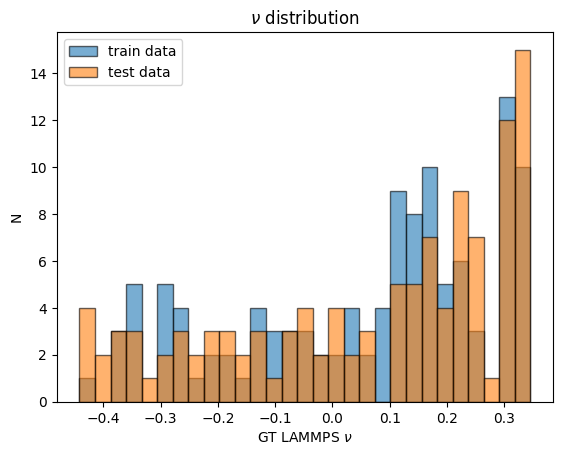

In [9]:
def visualize_nu_disribution(data: Dict):
    ps = {}
    all_values = []

    for data_type, sims in data.items():
        ps[data_type] = [calc_p_ratio_box_tensor(sim).item() for sim in sims]
        all_values.extend(ps[data_type])

    min_val = min(all_values)
    max_val = max(all_values)
    common_bins = np.linspace(min_val, max_val, 30) 

    for data_type, values in ps.items():
        plt.hist(
        values, 
        bins=common_bins, 
        edgecolor='black', 
        alpha=0.6, 
        label=f"{data_type} data"
    )

    plt.title("$\\nu$ distribution")
    plt.xlabel("GT LAMMPS $\\nu$")
    plt.ylabel("N")
    plt.legend()
    plt.show()

visualize_nu_disribution(data)


### Training GNN simulator

#### Initiaize Velocity simulator

In [10]:
mp_layers = 2
mlp = 3
hidden_size = 128
history = 3
device = "cuda"

init_graph = build_velocity_graph_correction(
    input_graphs=[data['train'][0][i].cpu().detach() for i in range(history + 1)],
    total_velocity=False,
    panic_at_positions=False
).to(device)

gnn_simulator = VelocityModel(init_graph, hidden_size, mp_layers, mlp).to(device)


In [11]:
rollout_eval_every = 5
rollout_eval_steps = 50
rollout_eval_sims = min(50, len(data["test"]))
rollout_eval_data = data["test"]
print(f"Rollout R2 evaluation: using {rollout_eval_sims} of {len(rollout_eval_data)} held-out test trajectories.")
rollout_eval_barostat_config = (
    barostat_parameters.node_optimizated
    if str(dataset_type) == "node_optimized"
    else barostat_parameters.stiff_optimized
)


def evaluate_rollout_r2(model, sims, *, eval_steps, max_sims, barostat_config, device):
    gt_p = []
    pred_p = []
    was_training = model.training
    model.eval()

    with torch.no_grad():
        for sim in sims[:max_sims]:
            if len(sim) < history + eval_steps + 1:
                continue

            input_graphs = [g.cpu().detach() for g in sim[: history + 1]]
            rollout = get_rollout(
                input_graphs=input_graphs,
                gnn_simulator=model,
                gnn_history=history,
                num_steps=eval_steps,
                barostat_config=barostat_config,
                device=device,
            )

            pred_p.append(calc_p_ratio_box_tensor(rollout).item())
            gt_p.append(calc_p_ratio_box_tensor(sim[: len(rollout)]).item())

    if was_training:
        model.train()

    if len(gt_p) < 2:
        return float("nan")
    return r2_score(gt_p, pred_p)


Rollout R2 evaluation: using 50 of 115 held-out test trajectories.


#### One-step Training loop

Here we train on a portion of training data with high Poisson's ratio, either $\nu > 0.1$ or $\nu > 0.2$.

In [ ]:
model_save_directory = os.path.join("./trained_models", f"{dataset_type}", "OST")
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 100
freeze_norm_epoch = 5
train_sims = 300
test_sims = 20
train_limit = 15
accumulation_steps = 10
learning_rate = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(
    f"Training: using {len(training_data)} of {len(data['train'])} train trajectories "
    f"with Poisson's ratio >= {poisson_threshold}."
)
print(f"Held-out test trajectories available: {len(data['test'])}.")

# Test data can be full Poisson's ratio range

optimizer = torch.optim.Adam(gnn_simulator.parameters(), lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)
ost_rollout_r2_history = {"epoch": [], "r2": []}

optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    total_acc_loss = 0
    total_test_loss = 0
    total_test_pos_mse = 0
    train_samples = 0
    test_samples = 0

    gnn_simulator.train()
    for sim in training_data:
        starting_points = [i for i in range(train_limit)]

        for i, idx in enumerate(starting_points):
            indices = [step + idx for step in range(history + 1)]
            target_idx = history + 1 + idx


            input_graphs_raw = [sim[k].detach().cpu() for k in indices]

            # Construct input graph
            input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device)

            # Construct ModelInputs
            model_inputs = ModelInputs(
                input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                input_graphs_raw[-1].to(device),
                sim[target_idx].to(device)
            )

            # Forward and Loss
            model_output = gnn_simulator(input_graph, is_training=True)
            acc_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)

            # Backward
            loss_for_backward = acc_loss / accumulation_steps
            loss_for_backward.backward()

            # Optimization
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()

            total_acc_loss += acc_loss.item()
            train_samples += 1

        optimizer.step()
        optimizer.zero_grad()

    # Held-out test evaluation
    with torch.no_grad():
        gnn_simulator.eval()
        for test_sim in data['test'][:test_sims]:
            
            starting_points = [i for i in range(train_limit)]

            for idx in starting_points:
                indices = [step + idx for step in range(history + 1)]
                target_idx = history + 1 + idx

                input_graphs_raw = [test_sim[k].detach().cpu() for k in indices]

                input_graph = build_velocity_graph_correction(input_graphs_raw, panic_at_positions=False).to(device) 

                test_inputs = ModelInputs(
                    input_graphs_raw[-2].to(device) if history > 0 else input_graphs_raw[-1].to(device),
                    input_graphs_raw[-1].to(device),
                    test_sim[target_idx].to(device),
                )

                # Forward and Loss
                model_output = gnn_simulator(input_graph, is_training=False)
                test_loss = huber_loss(gnn_simulator, model_output, test_inputs, is_training=False)

                # Update to next state and check position MSE
                pred_graph = gnn_simulator.update(test_inputs, model_output)
                pos_mse = torch.nn.functional.mse_loss(pred_graph.pos, test_sim[target_idx].to(device).pos)

                total_test_loss += test_loss.item()
                total_test_pos_mse += pos_mse.item()
                test_samples += 1

    lr_scheduler.step()

    ost_rollout_r2 = None
    if (epoch + 1) % rollout_eval_every == 0:
        ost_rollout_r2 = evaluate_rollout_r2(
            gnn_simulator,
            rollout_eval_data,
            eval_steps=rollout_eval_steps,
            max_sims=rollout_eval_sims,
            barostat_config=rollout_eval_barostat_config,
            device=device,
        )
        ost_rollout_r2_history["epoch"].append(epoch + 1)
        ost_rollout_r2_history["r2"].append(ost_rollout_r2)

    # Statistics
    avg_train_loss = total_acc_loss / train_samples
    avg_test_loss = total_test_loss / test_samples
    avg_test_pos_mse = total_test_pos_mse / test_samples

    # Save model
    if epoch % 1 == 0:
        gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))
        gnn_simulator.save_checkpoint(os.path.join(model_save_directory, "model_latest.pt"))

    t_stop = time.perf_counter()
    rollout_r2_msg = "" if ost_rollout_r2 is None else f" | Rollout R2: {ost_rollout_r2:.3f}"
    print(
        f"Epoch {epoch + 1:>3} | "
        f"Train Loss: {avg_train_loss:.3e} | "
        f"Test Loss: {avg_test_loss:.3e} | "
        f"Test Pos MSE: {avg_test_pos_mse:.3e} | "
        f"Time: {t_stop - t_start:.2f} s"
        f"{rollout_r2_msg}"
    )

gnn_simulator.save_checkpoint(os.path.join(model_save_directory, "model_latest.pt"))

Training: using 65 of 115 train trajectories with Poisson's ratio >= 0.1.
Held-out test trajectories available: 115.
Epoch   1 | Train Loss: 3.690e-01 | Test Loss: 3.871e-01 | Test Pos MSE: 2.201e-12 | Time: 10.97 s
Epoch   2 | Train Loss: 3.026e-01 | Test Loss: 4.006e-01 | Test Pos MSE: 2.150e-12 | Time: 10.70 s
Epoch   3 | Train Loss: 2.879e-01 | Test Loss: 3.556e-01 | Test Pos MSE: 2.038e-12 | Time: 10.46 s
Epoch   4 | Train Loss: 2.698e-01 | Test Loss: 3.583e-01 | Test Pos MSE: 2.038e-12 | Time: 10.12 s
Epoch   5 | Train Loss: 2.628e-01 | Test Loss: 3.337e-01 | Test Pos MSE: 1.915e-12 | Time: 22.16 s | Rollout R2: -0.166
Epoch   6 | Train Loss: 2.550e-01 | Test Loss: 3.198e-01 | Test Pos MSE: 1.848e-12 | Time: 10.17 s
Epoch   7 | Train Loss: 2.465e-01 | Test Loss: 3.298e-01 | Test Pos MSE: 1.885e-12 | Time: 10.16 s
Epoch   8 | Train Loss: 2.466e-01 | Test Loss: 3.129e-01 | Test Pos MSE: 1.756e-12 | Time: 10.16 s
Epoch   9 | Train Loss: 2.321e-01 | Test Loss: 3.270e-01 | Test Pos MS

#### Multi-step training loop

In [ ]:
model_save_directory = f"./trained_models/{dataset_type}/MST"
if not os.path.exists(model_save_directory):
    os.makedirs(model_save_directory, exist_ok=True)

epochs = 100
train_limit: int = 15
max_rollout_steps: int = 10
fresh: bool = True
freeze_norm_epoch: int = 5
learning_rate: float = 1e-3
gamma = 0.995

# Limit training data to high Poisson's ratio simulation
poisson_threshold = 0.1
training_data = [sim for sim in data['train'] if calc_p_ratio_box_tensor(sim) >= poisson_threshold][:train_sims]
print(
    f"Training: using {len(training_data)} of {len(data['train'])} train trajectories "
    f"with Poisson's ratio >= {poisson_threshold}."
)
print(f"Held-out test trajectories available: {len(data['test'])}.")

barostat_config = barostat_parameters.node_optimizated if str(dataset_type) == "node_optimized" else barostat_parameters.stiff_optimized

gnn_simulator.train()
params = filter(lambda p: p.requires_grad, gnn_simulator.parameters())
optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=0.0)
lr_scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma, last_epoch=-1)
mst_rollout_r2_history = {"epoch": [], "r2": []}


optimizer.zero_grad()
for epoch in range(epochs):
    t_start = time.perf_counter()

    if fresh:
        if epoch < 10:
            rollout_steps = 1
        elif epoch < 20:
            rollout_steps = 2
        elif epoch < 30:
            rollout_steps = 3
        elif epoch < 40:
            rollout_steps = 5
        elif epoch < 50:
            rollout_steps = 8
        else:
            rollout_steps = max_rollout_steps
    else:
        rollout_steps = max_rollout_steps

    # Trackers
    total_acc_loss = 0
    train_samples = 0

    # Freeze normalizers
    if epoch == freeze_norm_epoch:
        gnn_simulator.node_normalizer.frozen = True
        gnn_simulator.edge_normalizer.frozen = True
        gnn_simulator.output_normalizer.frozen = True

    for sim in training_data:
        # Get equilibrium bond lengths
        r0 = sim[0].edge_attr[:, -2]
        
        starting_points = [i for i in range(train_limit)]
        dump_period = barostat_config["default_skip"]

        for start_idx in starting_points:
            optimizer.zero_grad()

            indices = [step + start_idx for step in range(history + 1)]
            current_window_graphs = [sim[k].detach().to(device) for k in indices]

            b0 = current_window_graphs[-2].box_tensor[0]
            b1 = current_window_graphs[-1].box_tensor[0]
            box_compression_factor = b1 / b0

            if len(current_window_graphs) < 3:
                current_box_vel_y = estimate_initial_box_vel_y(
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    dump_period * barostat_config["dt"],
                )
            elif len(current_window_graphs) >= 3:
                current_box_vel_y = estimate_initial_box_vel_y_accurate(
                    current_window_graphs[-3],
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    dump_period * barostat_config["dt"],
                )
            else:
                raise Exception(f"Window size is too small : {len(current_window_graphs)}")


            rollout_loss = 0
            for step in range(rollout_steps):
                target_idx = history + 1 + start_idx + step
                target_graph = sim[target_idx].to(device)

                input_graph = build_velocity_graph_correction(current_window_graphs).to(device)

                model_inputs = ModelInputs(
                    current_window_graphs[-2],
                    current_window_graphs[-1],
                    target_graph,
                )

                model_output = gnn_simulator(input_graph, is_training=True)
                pred_graph_next = gnn_simulator.update(model_inputs, model_output)

                step_loss = huber_loss(gnn_simulator, model_output, model_inputs, is_training=True)
                rollout_loss += step_loss

                dt = barostat_config["dt"]  # lammps dt
                W_y = barostat_config["C_coupling"] * pred_graph_next.num_nodes * ((dump_period * dt) ** 2)
                damping = barostat_config["damping"] * pred_graph_next.num_nodes * (dump_period * dt)

                new_lx = pred_graph_next.box_tensor[0] * box_compression_factor
                new_ly, new_vel_y = update_box_y_thermodynamic(
                    positions=pred_graph_next.pos,
                    edge_index=model_inputs.cur_graph.edge_index,
                    edge_attr=model_inputs.cur_graph.edge_attr,
                    current_box=model_inputs.cur_graph.box_tensor,
                    r0=r0.to(pred_graph_next.pos.device),
                    box_vel_y=current_box_vel_y,  # Use ESTIMATED velocity
                    W_y=W_y,
                    damping=damping,
                    stride_dt=dump_period * dt,
                    target_pressure=barostat_config["target_pressure"],
                    temperature=barostat_config["temperature"],
                )

                new_box_tensor = torch.stack([new_lx, new_ly])
                current_box_vel_y = new_vel_y

                # Add new box and update edge_attr
                pred_graph_next.box_tensor = new_box_tensor
                pred_graph_next.edge_attr = get_correct_edge_attr(
                    pred_graph_next,
                    recompute_stiff=False,
                    panic_at_nontensor_box=True,
                )
                pred_graph_next.forces = compute_per_particle_forces(pred_graph_next, r0=r0.to(pred_graph_next.pos.device))

                pred_graph_next_detached = pred_graph_next.detach()

                # Update window: shift left, append new prediction
                current_window_graphs.pop(0)
                current_window_graphs.append(pred_graph_next_detached)

            final_loss = rollout_loss / rollout_steps
            final_loss.backward()

            # Clip gradients (essential for GNNs in physics)
            torch.nn.utils.clip_grad_norm_(gnn_simulator.parameters(), max_norm=1.0)
            optimizer.step()

            total_acc_loss += final_loss.item()
            train_samples += 1

    gnn_simulator.save_checkpoint(os.path.join(model_save_directory, f"checkpoint_epoch_{epoch}.pt"))
    gnn_simulator.save_checkpoint(os.path.join(model_save_directory, "model_latest.pt"))

    total_acc_loss /= train_samples
    lr_scheduler.step()

    mst_rollout_r2 = None
    if (epoch + 1) % rollout_eval_every == 0:
        mst_rollout_r2 = evaluate_rollout_r2(
            gnn_simulator,
            rollout_eval_data,
            eval_steps=rollout_eval_steps,
            max_sims=rollout_eval_sims,
            barostat_config=barostat_config,
            device=device,
        )
        mst_rollout_r2_history["epoch"].append(epoch + 1)
        mst_rollout_r2_history["r2"].append(mst_rollout_r2)

    t_stop = time.perf_counter()
    rollout_r2_msg = "" if mst_rollout_r2 is None else f" | Rollout R2: {mst_rollout_r2:.3f}"
    print(f"Epoch {epoch:<3} | steps: {rollout_steps:<2} | loss: {total_acc_loss:.4e} | {t_stop - t_start:.2f} s{rollout_r2_msg}.")


#### Save trained simulator model

In [ ]:
gnn_simulator.save_checkpoint(os.path.join(model_save_directory, "model_latest.pt"))

ost_history = globals().get("ost_rollout_r2_history", {"epoch": [], "r2": []})
mst_history = globals().get("mst_rollout_r2_history", {"epoch": [], "r2": []})

plt.figure(figsize=(6, 4))
if ost_history["epoch"]:
    plt.plot(ost_history["epoch"], ost_history["r2"], marker="o", label="OST")
if mst_history["epoch"]:
    plt.plot(mst_history["epoch"], mst_history["r2"], marker="o", label="MST, 1 step")
plt.xlabel("Epoch")
plt.ylabel("Test rollout $R^2$")
plt.title(f"Rollout R2 every {rollout_eval_every} epochs")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
